<h1 style="color:darkblue;">BULIDING THE MODELS WTH DIFFERENT TECHNIQUES</h1>

In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score
import ipywidgets as widgets
from ipywidgets import interact
import pickle
import os


In [2]:
poland_df = pd.read_csv("data/poland_df.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt_class,bankrupt_after_years
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,0


<h1 style="color:darkblue;">Addressing The Class Balance Issue</h1>

In [3]:
#splitting the Data
X = poland_df.drop(columns=["bankrupt_class","bankrupt_after_years"])
y = poland_df["bankrupt_after_years"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<h1 style="color:darkblue;">The Oversampling Technique</h1>

In [4]:
# Applying Random Oversampler on training data only
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

#Checking for the escence of OverSampling
y_train_over.value_counts(normalize=True).sort_index()

bankrupt_after_years
0    0.166667
1    0.166667
2    0.166667
3    0.166667
4    0.166667
5    0.166667
Name: proportion, dtype: float64

<h1 style="color:darkblue";>Ensemble Methods </h1>
<p>Ensemble Methods work by building multiple models on random subsets of the same data,compare predictionsand make final predictions</p>

<h2 style="color:darkblue";>The Random Forest Classifier </h2>

In [ ]:
classifier = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(n_jobs=-1, random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(classifier,X_train_over,y_train_over,cv=5, scoring="roc_auc_ovr",n_jobs=-1)

In [ ]:
features = X_train_over.columns

<h2 style="color:darkblue";>Hyperparameter Tuning</h2>

In [20]:
params_rf = {
    "randomforestclassifier__n_estimators": [100],
    "randomforestclassifier__max_depth": range(5, 21),
    "randomforestclassifier__max_features": ["sqrt"],
    "simpleimputer__strategy": ["mean", "median"]
}
params_rf

{'randomforestclassifier__n_estimators': [100],
 'randomforestclassifier__max_depth': range(5, 21),
 'randomforestclassifier__max_features': ['sqrt'],
 'simpleimputer__strategy': ['mean', 'median']}

<h2 style="color:darkblue";>The GridSearchCV</h2>

In [21]:
model_rf = GridSearchCV(
    classifier,
    param_grid=params_rf,
    cv=5,
    scoring="roc_auc_ovr",
    verbose=1
)
model_rf.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'randomforestclassifier__max_depth': range(5, 21), 'randomforestclassifier__max_features': ['sqrt'], 'randomforestclassifier__n_estimators': [100], 'simpleimputer__strategy': ['mean', 'median']}"
,scoring,'roc_auc_ovr'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [22]:
results = model_rf.cv_results_
cv_results = pd.DataFrame(results)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__max_features,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,25.707510,1.060723,0.461659,0.168375,5,sqrt,100,mean,"{'randomforestclassifier__max_depth': 5, 'rand...",0.819532,0.825629,0.823670,0.824879,0.823206,0.823383,0.002109,31
1,25.631378,0.981417,0.373041,0.051450,5,sqrt,100,median,"{'randomforestclassifier__max_depth': 5, 'rand...",0.815194,0.815811,0.816486,0.814779,0.814787,0.815411,0.000656,32
2,31.359855,2.984723,0.435781,0.039499,6,sqrt,100,mean,"{'randomforestclassifier__max_depth': 6, 'rand...",0.886672,0.884307,0.885328,0.884781,0.885157,0.885249,0.000793,29
3,35.564943,4.952812,0.500859,0.034327,6,sqrt,100,median,"{'randomforestclassifier__max_depth': 6, 'rand...",0.884036,0.883865,0.880830,0.882890,0.881617,0.882648,0.001252,30
4,33.569289,0.883528,0.476592,0.035474,7,sqrt,100,mean,"{'randomforestclassifier__max_depth': 7, 'rand...",0.934502,0.940724,0.938026,0.940019,0.935565,0.937767,0.002425,27


<h2 style="color:darkblue";>Extracting The Best Parameters</h2>

In [23]:
best_params_rf = model_rf.best_params_
best_score_rf = model_rf.best_score_
best_model_rf = model_rf.best_estimator_


print("Best Model:", best_model_rf)
print("Best params:", best_params_rf)
print("Best Score:", best_score_rf)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=19, n_jobs=-1,
                                        random_state=42))])
Best params: {'randomforestclassifier__max_depth': 19, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__n_estimators': 100, 'simpleimputer__strategy': 'median'}
Best Score: 0.9999779374467325


In [ ]:
# Extract top 20 features from the full feature random forest
importances = best_model_rf.named_steps["randomforestclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=X_train_over.columns).sort_values(ascending=False)

top20_features = feat_imp.head(20).index.tolist()

print("Top 20 Features:")
print(top20_features)

Top 20 Features:
['Attr27', 'Attr24', 'Attr46', 'Attr21', 'Attr34', 'Attr11', 'Attr40', 'Attr13', 'Attr29', 'Attr39', 'Attr35', 'Attr25', 'Attr58', 'Attr55', 'Attr61', 'Attr6', 'Attr42', 'Attr56', 'Attr22', 'Attr41']


In [25]:
# Create reduced train/test datasets using RF-selected top 20 features
X_train_top20 = X_train_over[top20_features]
X_test_top20 = X_test[top20_features]

print(X_train_top20.shape)
print(X_test_top20.shape)

(198306, 20)
(8681, 20)


In [26]:
# retraining RF only on the selected top 20 features
classifier_top20 = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(n_jobs=-1, random_state=42)
)

model_rf_top20 = GridSearchCV(
    classifier_top20,
    param_grid=params_rf,
    cv=5,
    scoring="roc_auc_ovr",
    # n_jobs=-1,
    verbose=1
)
model_rf_top20.fit(X_train_top20, y_train_over)

best_model_rf_top20 = model_rf_top20.best_estimator_
print("Best Model (top-20):", best_model_rf_top20)
print("Best Params (top-20):", model_rf_top20.best_params_)
print("Best Score (top-20):", model_rf_top20.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Model (top-20): Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=20, n_jobs=-1,
                                        random_state=42))])
Best Params (top-20): {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__n_estimators': 100, 'simpleimputer__strategy': 'mean'}
Best Score (top-20): 0.9999858894207492


<h2 style="color:darkblue";>Classification Report</h2>

In [27]:
report_rf = classification_report(y_test, model_rf_top20.predict(X_test_top20))
print(report_rf)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8263
           1       0.12      0.02      0.04        82
           2       0.21      0.04      0.07       103
           3       0.07      0.01      0.02        99
           4       0.05      0.01      0.02        80
           5       0.32      0.17      0.22        54

    accuracy                           0.95      8681
   macro avg       0.29      0.21      0.22      8681
weighted avg       0.92      0.95      0.93      8681



<h2 style="color:darkblue";>The Confusion Matrix </h2>

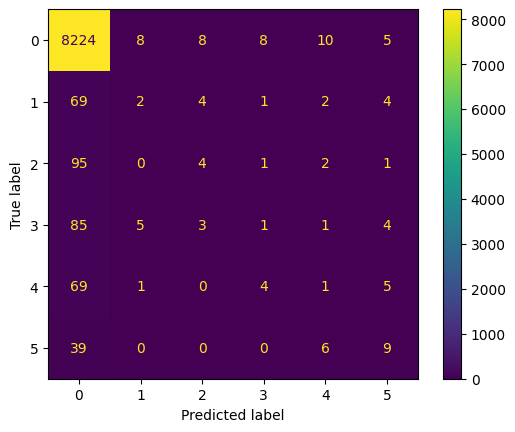

In [28]:
ConfusionMatrixDisplay.from_estimator(model_rf_top20, X_test_top20, y_test);

<h2 style="color:darkblue";>Feature Importance</h2>

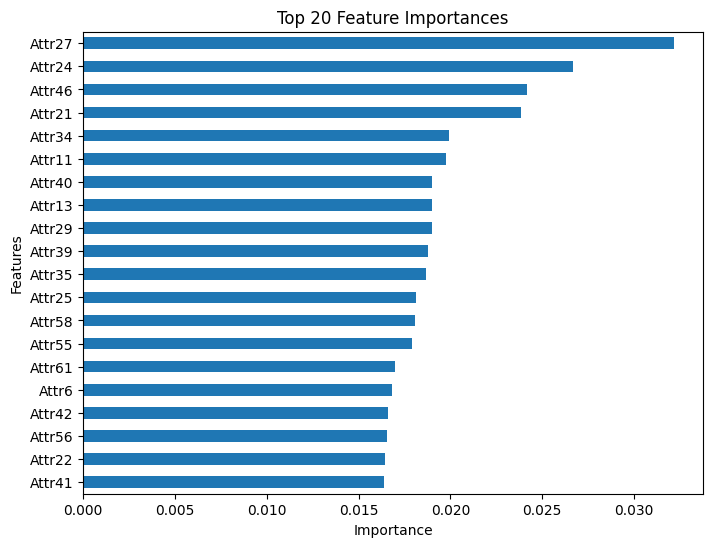

In [ ]:
# top 20 features based on full feature RF importance
feat_imp.head(20).sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
X_test_rf_top20 = X_test_top20.copy()

<h2 style="color:darkblue";> GRADIENT BOOSTING TREES</h2>
<p>Fitting multiple models in sequence using all the training data</p>


In [ ]:
# ranking feature importance
gb_ranker = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42, n_estimators=80, max_depth=3, learning_rate=0.1)
)
gb_ranker.fit(X_train_over, y_train_over)

importances = gb_ranker.named_steps["gradientboostingclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=X_train_over.columns).sort_values(ascending=False)
top20_features = feat_imp.head(20).index.tolist()

# reduced traintest sets to the 20 most important features
X_train_top20 = X_train_over[top20_features]
X_test_top20 = X_test[top20_features]

print("Selected top features:", len(top20_features))
print(X_train_top20.shape, X_test_top20.shape)

Selected top features: 20
(198306, 20) (8681, 20)


<h2 style="color:darkblue";>Hyperparameter Tuning</h2>

In [6]:
params_boost = {
    "simpleimputer__strategy": ["median"],
    "gradientboostingclassifier__n_estimators": [80, 120],
    "gradientboostingclassifier__max_depth": [2, 3],
    "gradientboostingclassifier__learning_rate": [0.05, 0.1],
    "gradientboostingclassifier__subsample": [0.8, 1.0],
}
params_boost

{'simpleimputer__strategy': ['median'],
 'gradientboostingclassifier__n_estimators': [80, 120],
 'gradientboostingclassifier__max_depth': [2, 3],
 'gradientboostingclassifier__learning_rate': [0.05, 0.1],
 'gradientboostingclassifier__subsample': [0.8, 1.0]}

In [7]:
model_boost = GridSearchCV(
    make_pipeline(
        SimpleImputer(),
        GradientBoostingClassifier(random_state=42)
    ),
    param_grid=params_boost,
    cv=3,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=1
)
model_boost.fit(X_train_top20, y_train_over)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'gradientboostingclassifier__learning_rate': [0.05, 0.1], 'gradientboostingclassifier__max_depth': [2, 3], 'gradientboostingclassifier__n_estimators': [80, 120], 'gradientboostingclassifier__subsample': [0.8, 1.0], ...}"
,scoring,'roc_auc_ovr'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [8]:
results_boost = model_boost.cv_results_
cv_results_boost = pd.DataFrame(results_boost)
cv_results_boost.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_gradientboostingclassifier__subsample,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,961.481249,7.706881,3.017462,0.260821,0.05,2,80,0.8,median,{'gradientboostingclassifier__learning_rate': ...,0.805990,0.809508,0.807464,0.807654,0.001443,15
1,1147.403417,12.468477,3.551649,0.488771,0.05,2,80,1.0,median,{'gradientboostingclassifier__learning_rate': ...,0.806674,0.806909,0.804689,0.806091,0.000996,16
2,1342.576240,77.314472,3.568188,0.649557,0.05,2,120,0.8,median,{'gradientboostingclassifier__learning_rate': ...,0.833033,0.835004,0.834779,0.834272,0.000881,13
3,1227.077427,113.390225,1.912731,0.062168,0.05,2,120,1.0,median,{'gradientboostingclassifier__learning_rate': ...,0.832636,0.832557,0.831154,0.832116,0.000681,14
4,874.758437,31.974393,3.076133,0.888659,0.05,3,80,0.8,median,{'gradientboostingclassifier__learning_rate': ...,0.888093,0.889794,0.888935,0.888941,0.000694,8


In [9]:
best_params_boost = model_boost.best_params_
best_score_boost = model_boost.best_score_
best_model_boost = model_boost.best_estimator_


print("Best Model:", best_model_boost)
print("Best params:", best_params_boost)
print("Best Score:", best_score_boost)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(n_estimators=120, random_state=42,
                                            subsample=0.8))])
Best params: {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 3, 'gradientboostingclassifier__n_estimators': 120, 'gradientboostingclassifier__subsample': 0.8, 'simpleimputer__strategy': 'median'}
Best Score: 0.9675135908634562


In [10]:
print("Top 20 Features:")
print(top20_features)

feat_imp.head(20)

Top 20 Features:
['Attr27', 'Attr34', 'Attr21', 'Attr24', 'Attr46', 'Attr26', 'Attr11', 'Attr6', 'Attr25', 'Attr13', 'Attr15', 'Attr29', 'Attr40', 'Attr5', 'Attr39', 'Attr57', 'Attr58', 'Attr35', 'Attr43', 'Attr41']


Attr27    0.102297
Attr34    0.082031
Attr21    0.050345
Attr24    0.036269
Attr46    0.036174
Attr26    0.033451
Attr11    0.033036
Attr6     0.028779
Attr25    0.023952
Attr13    0.023668
Attr15    0.023170
Attr29    0.023067
Attr40    0.021900
Attr5     0.018257
Attr39    0.017179
Attr57    0.016957
Attr58    0.016500
Attr35    0.015822
Attr43    0.015415
Attr41    0.015366
dtype: float64

In [ ]:
print(X_train_top20.shape)
print(X_test_top20.shape)

(198306, 20)
(8681, 20)


In [ ]:
# Save GB test set for evaluation
X_test_boost_top20 = X_test_top20.copy()

# Best tuned GB model trained on top 20 features
best_model_boost = model_boost.best_estimator_
best_params_boost = model_boost.best_params_
best_score_boost = model_boost.best_score_

model_boost_top20 = model_boost
best_model_boost_top20 = best_model_boost

print("Best Model (top-20):", best_model_boost_top20)
print("Best Params (top-20):", best_params_boost)
print("Best Score (top-20):", best_score_boost)

Best Model (top-20): Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(n_estimators=120, random_state=42,
                                            subsample=0.8))])
Best Params (top-20): {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 3, 'gradientboostingclassifier__n_estimators': 120, 'gradientboostingclassifier__subsample': 0.8, 'simpleimputer__strategy': 'median'}
Best Score (top-20): 0.9675135908634562


<h2 style="color:darkblue";>The Classification Report</h2>

In [13]:
report_boost = classification_report(y_test, model_boost_top20.predict(X_test_top20))
print(report_boost)

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      8263
           1       0.05      0.23      0.08        82
           2       0.05      0.18      0.08       103
           3       0.04      0.21      0.07        99
           4       0.03      0.12      0.05        80
           5       0.06      0.35      0.10        54

    accuracy                           0.78      8681
   macro avg       0.20      0.32      0.21      8681
weighted avg       0.95      0.78      0.85      8681



<h2 style="color:darkblue";>Feature Importances</h2>

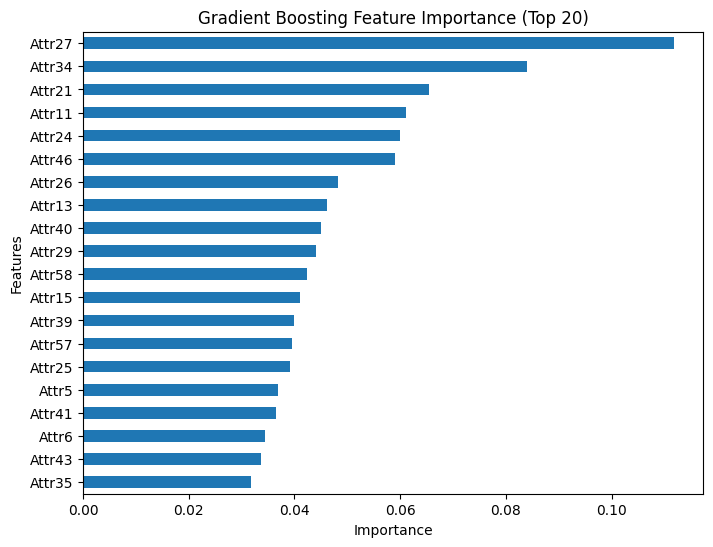

In [14]:
importances = best_model_boost.named_steps["gradientboostingclassifier"].feature_importances_
feat_imp_top20 = pd.Series(importances, index=top20_features).sort_values()

feat_imp_top20.plot(kind="barh", figsize=(8, 6))
plt.title("Gradient Boosting Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Features");

<h1 style="color:darkblue";> The Correlation Matrix</h2>

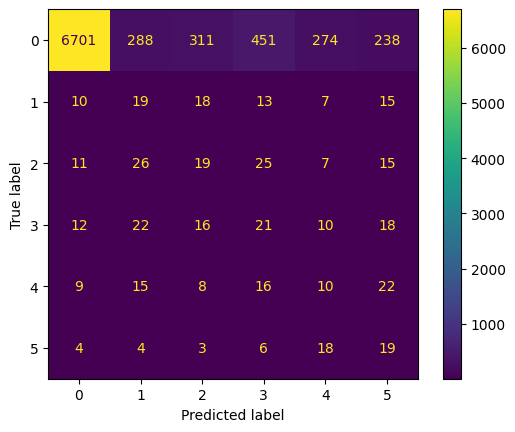

In [15]:
ConfusionMatrixDisplay.from_estimator(model_boost_top20, X_test_top20, y_test);

<h1 style="color:darkblue";>XGBOOST</h1>

In [ ]:
classifier_xgb = make_pipeline(
    XGBClassifier(random_state=42, eval_metric="mlogloss")
 )

# fitting XGBoost on all oversampled training features to rank 20 most significant features
classifier_xgb.fit(X_train_over, y_train_over)

xgb_importances = classifier_xgb.named_steps["xgbclassifier"].feature_importances_
xgb_feature_ranking = pd.Series(xgb_importances, index=X_train_over.columns).sort_values(ascending=False)
top_20_features_xgb = xgb_feature_ranking.head(20).index.tolist()

print("Top 20 XGBoost features:")
print(top_20_features_xgb)

# reducing the data to the 20 most important features
X_train_xgb = X_train_over[top_20_features_xgb]
X_test_xgb = X_test[top_20_features_xgb]

cross_val_scores_dt = cross_val_score(
    classifier_xgb, X_train_xgb, y_train_over, cv=5, scoring="roc_auc_ovr", n_jobs=-1
 )

#hyperparameter Tuning
params_xgb = {
    "xgbclassifier__n_estimators": [100],
    "xgbclassifier__learning_rate": [0.01, 0.05, 0.1],
    "xgbclassifier__max_depth": range(3, 8),
    "xgbclassifier__reg_alpha": [0, 0.1]
}
params_xgb


#GridSearchCV
model_xgb = GridSearchCV(
    classifier_xgb,
    param_grid=params_xgb,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=1
)
model_xgb.fit(X_train_xgb, y_train_over)

Top 20 XGBoost features:
['Attr11', 'Attr27', 'Attr34', 'Attr26', 'Attr6', 'Attr39', 'Attr7', 'Attr22', 'Attr21', 'Attr4', 'Attr13', 'Attr42', 'Attr48', 'Attr30', 'Attr35', 'Attr59', 'Attr25', 'Attr24', 'Attr43', 'Attr38']
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgbclassifier__learning_rate': [0.01, 0.05, ...], 'xgbclassifier__max_depth': range(3, 8), 'xgbclassifier__n_estimators': [100], 'xgbclassifier__reg_alpha': [0, 0.1]}"
,scoring,'roc_auc_ovr'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [36]:
results_xgb = model_xgb.cv_results_
cv_results_xgb = pd.DataFrame(results_xgb)
cv_results_xgb.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__reg_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,33.339476,0.062821,0.851667,0.011787,0.01,3,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.778774,0.777477,0.778498,0.780037,0.779862,0.778930,0.000940,30
1,33.866005,0.280495,0.872599,0.031023,0.01,3,100,0.1,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.778687,0.777415,0.778339,0.780172,0.780068,0.778936,0.001053,29
2,42.255935,1.975078,1.301794,0.058587,0.01,4,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.830786,0.828212,0.832158,0.833572,0.834014,0.831748,0.002100,27
3,63.496984,9.705571,1.628899,0.180339,0.01,4,100,0.1,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.830878,0.827983,0.832095,0.833420,0.833843,0.831644,0.002106,28
4,75.840623,3.719723,2.808914,0.820447,0.01,5,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.882237,0.880934,0.889553,0.885490,0.887644,0.885172,0.003224,23


In [37]:
best_params_xgb = model_xgb.best_params_
best_score_xgb = model_xgb.best_score_
best_model_xgb = model_xgb.best_estimator_


print("Best Model:", best_model_xgb)
print("Best params:", best_params_xgb)
print("Best Score:", best_score_xgb)

Best Model: Pipeline(steps=[('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints

<h2 style="color:darkblue";>The Correlation Matrix</h2>

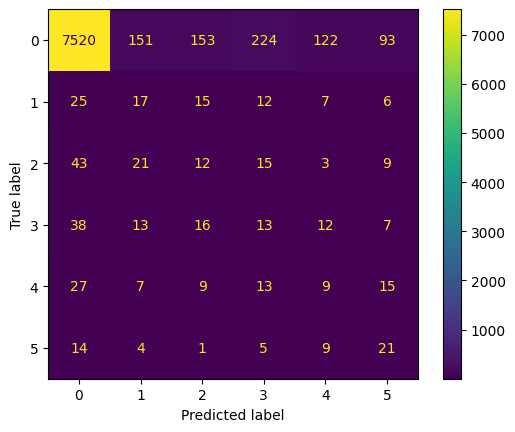

In [38]:
ConfusionMatrixDisplay.from_estimator(model_xgb, X_test_xgb, y_test);

<h2 style="color:darkblue";>The Classification Report</h2>

In [39]:
report_xgb = classification_report(y_test, model_xgb.predict(X_test_xgb) )
print(report_xgb)

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      8263
           1       0.08      0.21      0.12        82
           2       0.06      0.12      0.08       103
           3       0.05      0.13      0.07        99
           4       0.06      0.11      0.07        80
           5       0.14      0.39      0.20        54

    accuracy                           0.87      8681
   macro avg       0.23      0.31      0.25      8681
weighted avg       0.94      0.87      0.90      8681



<h2 style="color:darkblue";>Feature Importance</h2>

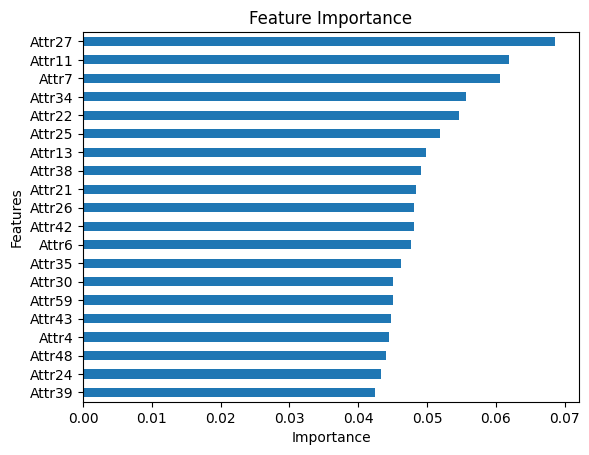

In [40]:
importances = best_model_xgb.named_steps["xgbclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=top_20_features_xgb).sort_values()

feat_imp = pd.Series(importances, index=top_20_features_xgb).sort_values()

feat_imp.tail(20).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

<h2 style="color:darkblue";>Saving Models</h2>

In [41]:
os.makedirs("models", exist_ok=True)

# Saving all the models
with open("models/model_rf.pkl", "wb") as f:
    pickle.dump(model_rf.best_estimator_, f)

with open("models/model_boost.pkl", "wb") as f:
    pickle.dump(model_boost.best_estimator_, f)

with open("models/model_xgb.pkl", "wb") as f:
    pickle.dump(model_xgb.best_estimator_, f)

<h2 style="color:darkblue";> Evaluating All Models</h2>

In [ ]:
models = {
    "Random Forest": model_rf_top20,
    "Gradient Boosting": model_boost,
    "XGBoost": model_xgb
}

results = []
for name, model in models.items():
    estimator = model.best_estimator_

    selected_features = estimator.feature_names_in_
    X_eval = X_test[selected_features]
    
    y_pred = estimator.predict(X_eval)
    y_prob = estimator.predict_proba(X_eval)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC (OvR)": roc_auc_score(y_test, y_prob, multi_class="ovr"),
        "Best CV Score": model.best_score_
    })

all_model_evaluation_df = pd.DataFrame(results).set_index("Model").round(4)
all_model_evaluation_df

,Accuracy,F1 (weighted),ROC-AUC (OvR),Best CV Score
Model,,,,
Random Forest,0.9493,0.9324,0.8548,1.0000
Gradient Boosting,0.7821,0.8534,0.8427,0.9675
XGBoost,0.8746,0.9034,0.8504,0.9989
